# ✈️ Airline Passenger Satisfaction — Mid Project

**Author:** Hisham Mohamed
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy · Streamlit

---

## 1. Introduction

### 1.1 Domain
Airlines compete fiercely on customer experience. Every passenger who leaves dissatisfied is a passenger who may switch to a competitor next time. This project analyses an **airline passenger satisfaction survey**: each row is one passenger, describing *who* they are (gender, age, loyalty), *how* they travelled (travel purpose, cabin class, flight distance, delays) and *how they rated* 14 services of the journey on a 0–5 scale, together with their overall satisfaction.

### 1.2 Dataset description

| Column | Meaning |
|---|---|
| `Unnamed: 0` | Leftover row index from a previous export (no meaning) |
| `id` | Unique passenger identifier |
| `Gender` | Female / Male |
| `Customer Type` | Loyal Customer / disloyal Customer |
| `Age` | Passenger age in years |
| `Type of Travel` | Business travel / Personal Travel |
| `Class` | Cabin class: Business, Eco, Eco Plus |
| `Flight Distance` | Flight distance in miles |
| 14 service columns | Ratings 1–5 of: Inflight wifi, Departure/Arrival time convenience, Ease of online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room, Baggage handling, Check-in service, Inflight service, Cleanliness — **0 means "Not Applicable"** |
| `Departure Delay in Minutes` | Minutes the departure was delayed |
| `Arrival Delay in Minutes` | Minutes the arrival was delayed |
| `satisfaction` | Target: *satisfied* or *neutral or dissatisfied* |

### 1.3 Research questions
1. **Q1 – Overall:** What share of passengers are satisfied?
2. **Q2 – Who:** How does satisfaction differ across passenger segments (Gender, Customer Type, Type of Travel, Class, Age group)?
3. **Q3 – What:** Which services have the strongest relationship with satisfaction, and where are the biggest rating gaps?
4. **Q4 – Delays:** Do departure and arrival delays reduce satisfaction?
5. **Q5 – Distance:** Does flight distance affect satisfaction, and does the effect depend on cabin class?
6. **Q6 – Combined:** Which combination of travel type and class produces the happiest and the unhappiest passengers?

## 2. Setup

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Same colours in every chart: blue = satisfied, orange = not satisfied
BLUE, ORANGE, YELLOW = "#2a78d6", "#eb6834", "#eda100"

## 3. Data Gathering

In [2]:
raw_df = pd.read_csv("Data.csv")
print("Rows:", raw_df.shape[0], "| Columns:", raw_df.shape[1])
raw_df.head()

Rows: 25976 | Columns: 25


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


## 4. Data Assessment
Before cleaning, we look for problems in the data.

In [3]:
# Column types and non-empty values
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [4]:
# Missing values and duplicated rows
missing = raw_df.isna().sum()
print("Missing values:\n", missing[missing > 0])
print("\nDuplicated rows:", raw_df.duplicated().sum())

Missing values:
 Arrival Delay in Minutes    83
dtype: int64

Duplicated rows: 0


In [5]:
# Are the text labels written consistently?
for column in ["Customer Type", "Type of Travel", "Class", "satisfaction"]:
    print(column, "->", raw_df[column].unique().tolist())

Customer Type -> ['Loyal Customer', 'disloyal Customer']
Type of Travel -> ['Business travel', 'Personal Travel']
Class -> ['Eco', 'Business', 'Eco Plus']
satisfaction -> ['satisfied', 'neutral or dissatisfied']


In [6]:
# The 14 service ratings should be from 1 to 5. A rating of 0 means "Not Applicable".
service_columns = list(raw_df.loc[:, "Inflight wifi service":"Cleanliness"].columns)
print("Ratings equal to 0:", (raw_df[service_columns] == 0).sum().sum())

Ratings equal to 0: 4202


In [7]:
# Ranges of the numeric columns
raw_df[["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]].describe().round(1)

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.0,25976.0,25976.0,25893.0
mean,39.6,1193.8,14.3,14.7
std,15.1,998.7,37.4,37.5
min,7.0,31.0,0.0,0.0
25%,27.0,414.0,0.0,0.0
50%,40.0,849.0,0.0,0.0
75%,51.0,1744.0,12.0,13.0
max,85.0,4983.0,1128.0,1115.0


In [8]:
# Some delays are very long (up to 1,128 min). Are they real?
# If departure and arrival delays move together, the long delays are genuine and not typing errors.
raw_df["Departure Delay in Minutes"].corr(raw_df["Arrival Delay in Minutes"]).round(3)

np.float64(0.965)

### Problems found
1. **83 missing values** in `Arrival Delay in Minutes` (also stored as decimal numbers instead of whole minutes).
2. **4,202 ratings of 0** — they mean "Not Applicable", not a bad rating, so they would wrongly pull the averages down.
3. **Inconsistent labels:** `disloyal Customer`, `Business travel`, the abbreviation `Eco`, and the target in lower case.
4. `Unnamed: 0` is a **useless column** (an old row number).
5. **Column names** with spaces and slashes are awkward to use in code.
6. **Very long delays** — the correlation of 0.96 between departure and arrival delay shows they are real, so they are **kept**.

No duplicated rows were found.

## 5. Data Cleaning
We work on a copy so the raw data stays unchanged. Each step fixes one problem from the list above.

In [9]:
clean_df = raw_df.copy()

# Problem 4: drop the useless index column
clean_df = clean_df.drop(columns=["Unnamed: 0"])

In [10]:
# Problem 5: easy column names (lower case, no spaces or slashes)
def to_snake_case(name):
    """'Departure Delay in Minutes' -> 'departure_delay'"""
    return name.lower().replace(" in minutes", "").replace("/", " ").replace("-", " ").replace(" ", "_")

clean_df.columns = [to_snake_case(column) for column in clean_df.columns]
service_columns = list(clean_df.loc[:, "inflight_wifi_service":"cleanliness"].columns)
print(clean_df.columns.tolist())

['id', 'gender', 'customer_type', 'age', 'type_of_travel', 'class', 'flight_distance', 'inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on_board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness', 'departure_delay', 'arrival_delay', 'satisfaction']


In [11]:
# Problem 3: consistent labels
label_fixes = {
    "customer_type": {"disloyal Customer": "Disloyal Customer"},
    "type_of_travel": {"Business travel": "Business Travel"},
    "class": {"Eco": "Economy", "Eco Plus": "Economy Plus"},
    "satisfaction": {"satisfied": "Satisfied", "neutral or dissatisfied": "Neutral or Dissatisfied"},
}
clean_df = clean_df.replace(label_fixes)

for column in label_fixes:
    print(column, "->", clean_df[column].unique().tolist())

customer_type -> ['Loyal Customer', 'Disloyal Customer']
type_of_travel -> ['Business Travel', 'Personal Travel']
class -> ['Economy', 'Business', 'Economy Plus']
satisfaction -> ['Satisfied', 'Neutral or Dissatisfied']


In [12]:
# Problem 1: fill the missing arrival delays with the same passenger's departure delay
# (the two delays are 96% correlated, so this is a better guess than the average)
clean_df["arrival_delay"] = clean_df["arrival_delay"].fillna(clean_df["departure_delay"]).astype(int)
print("Missing values left:", clean_df.isna().sum().sum())

Missing values left: 0


In [13]:
# Problem 2: rating 0 = "Not Applicable" -> empty value, so it is ignored when averages are calculated
clean_df[service_columns] = clean_df[service_columns].replace(0, np.nan)
print("Ratings now go from", clean_df[service_columns].min().min(), "to", clean_df[service_columns].max().max())

Ratings now go from 1.0 to 5.0


In [14]:
# New helper columns that make comparing groups easy
clean_df["age_group"] = pd.cut(clean_df["age"], bins=[0, 17, 29, 44, 59, 120],
                               labels=["Child (<18)", "Young Adult (18-29)", "Adult (30-44)",
                                       "Middle-Aged (45-59)", "Senior (60+)"])
clean_df["distance_group"] = pd.cut(clean_df["flight_distance"], bins=[0, 800, 2000, np.inf],
                                    labels=["Short-haul (<800 mi)", "Medium-haul (800-2000 mi)",
                                            "Long-haul (>2000 mi)"])
clean_df["delay_group"] = pd.cut(clean_df["arrival_delay"], bins=[-1, 0, 15, 60, np.inf],
                                 labels=["On time", "1-15 min", "16-60 min", "> 60 min"])
clean_df["average_service_rating"] = clean_df[service_columns].mean(axis=1).round(2)
clean_df["is_satisfied"] = (clean_df["satisfaction"] == "Satisfied").astype(int)   # 1 = satisfied, 0 = not

# A fixed order for the groups, so the charts show them in a logical order
group_orders = {
    "gender": ["Female", "Male"],
    "customer_type": ["Loyal Customer", "Disloyal Customer"],
    "type_of_travel": ["Business Travel", "Personal Travel"],
    "class": ["Economy", "Economy Plus", "Business"],
    "satisfaction": ["Satisfied", "Neutral or Dissatisfied"],
}
for column, order in group_orders.items():
    clean_df[column] = pd.Categorical(clean_df[column], categories=order)

clean_df[["age", "age_group", "flight_distance", "distance_group", "arrival_delay", "delay_group",
          "is_satisfied"]].head()

,age,age_group,flight_distance,distance_group,arrival_delay,delay_group,is_satisfied
0,52,Middle-Aged (45-59),160,Short-haul (<800 mi),44,16-60 min,1
1,36,Adult (30-44),2863,Long-haul (>2000 mi),0,On time,1
2,20,Young Adult (18-29),192,Short-haul (<800 mi),0,On time,0
3,44,Adult (30-44),3377,Long-haul (>2000 mi),6,1-15 min,1
4,49,Middle-Aged (45-59),1182,Medium-haul (800-2000 mi),20,16-60 min,1


In [15]:
# Final check, then save the clean data (it is used by the Streamlit dashboard)
print("Rows, columns:", clean_df.shape)
clean_df.to_csv("Data_Cleaned.csv", index=False)

Rows, columns: (25976, 29)


### Cleaning summary
| Problem | What we did |
|---|---|
| 83 missing arrival delays | Filled with the passenger's departure delay, then converted to whole minutes |
| Rating 0 = "Not Applicable" | Replaced with an empty value so it is ignored in averages |
| Inconsistent labels | Written the same way everywhere (`Eco` → `Economy`) |
| Useless `Unnamed: 0` column | Dropped |
| Messy column names | Converted to `snake_case` |
| Very long delays | Checked and kept (they are real) |
| — | Added age, distance and delay groups, the average rating and a 1/0 satisfied column |

No rows were deleted: the clean data still has all 25,976 passengers.

## 6. Univariate Analysis (one variable at a time)

In [16]:
def short_label(label):
    """Put the bracket part of a long group name on a new line so labels do not overlap."""
    return str(label).replace(" (", "\n(")


def plot_counts(column, ax, title):
    """Bar chart: number of passengers in each group."""
    counts = clean_df[column].value_counts(sort=False)
    ax.bar([short_label(label) for label in counts.index], counts.values, color=BLUE)
    for x, value in enumerate(counts.values):
        ax.text(x, value, f"{value:,}", ha="center", va="bottom")
    ax.set_title(title)
    ax.set_ylabel("Passengers")


def satisfaction_rate(column):
    """% of satisfied passengers in each group of a column."""
    return (clean_df.groupby(column, observed=True)["is_satisfied"].mean() * 100).round(1)


def plot_satisfaction_rate(column, ax, title):
    """Bar chart: % satisfied in each group. Blue = above the average, orange = below. Dashed line = average."""
    rates = satisfaction_rate(column)
    average = clean_df["is_satisfied"].mean() * 100
    ax.bar([short_label(label) for label in rates.index], rates.values,
           color=[BLUE if rate >= average else ORANGE for rate in rates])
    for x, value in enumerate(rates.values):
        ax.text(x, value + 1, f"{value:.0f}%", ha="center")
    ax.axhline(average, color="black", linestyle="--", label=f"Average {average:.0f}%")
    ax.set_ylim(0, 100)
    ax.set_ylabel("% satisfied")
    ax.set_title(title)
    ax.legend()

### 6.1 Satisfaction — answers Q1

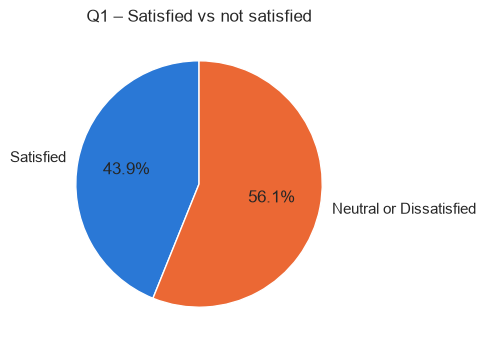

In [17]:
counts = clean_df["satisfaction"].value_counts(sort=False)   # Satisfied first, so the colours match
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=[BLUE, ORANGE], startangle=90)
plt.title("Q1 – Satisfied vs not satisfied")
plt.show()

**Q1:** Only **43.9 %** of passengers are satisfied; **56.1 %** are neutral or dissatisfied.

### 6.2 Who are the passengers?

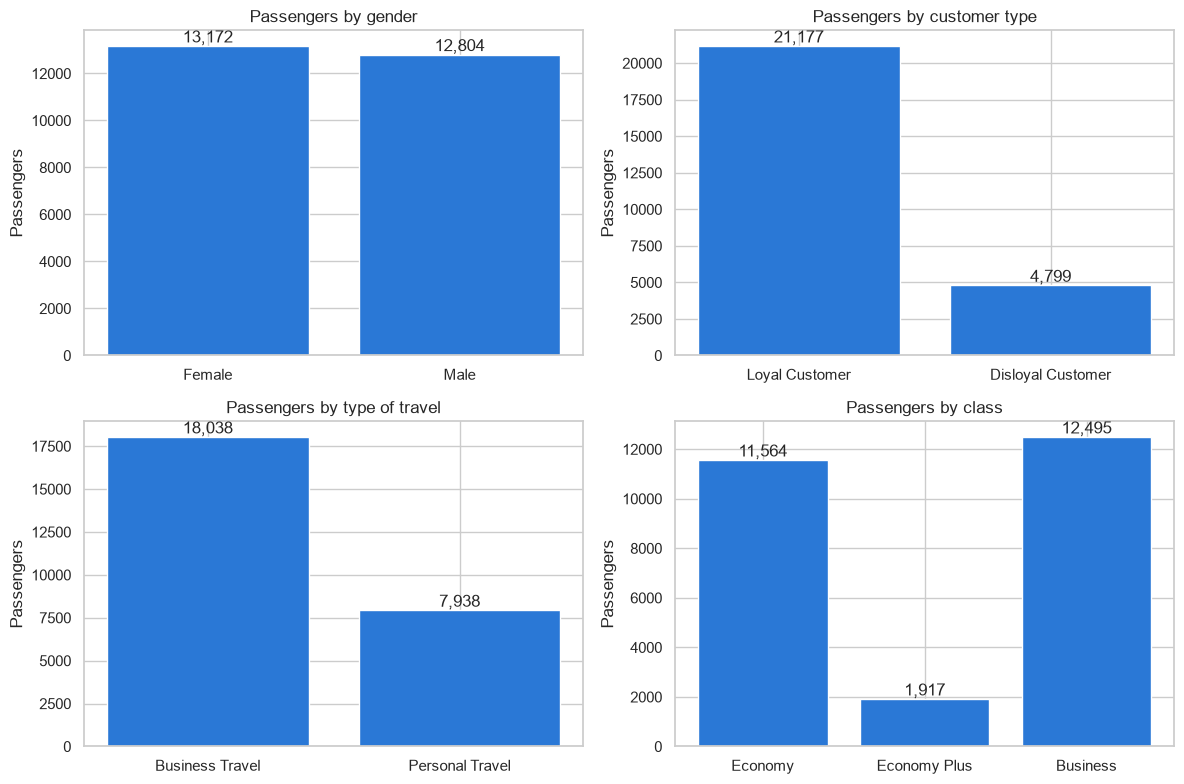

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.flat, ["gender", "customer_type", "type_of_travel", "class"]):
    plot_counts(column, ax, "Passengers by " + column.replace("_", " "))
plt.tight_layout()
plt.show()

- Gender is balanced (about half women, half men).
- **82 %** are loyal customers and **69 %** travel for business.
- Most passengers fly **Business** (12,495) or **Economy** (11,564); Economy Plus is small (1,917).

### 6.3 Age and flight distance

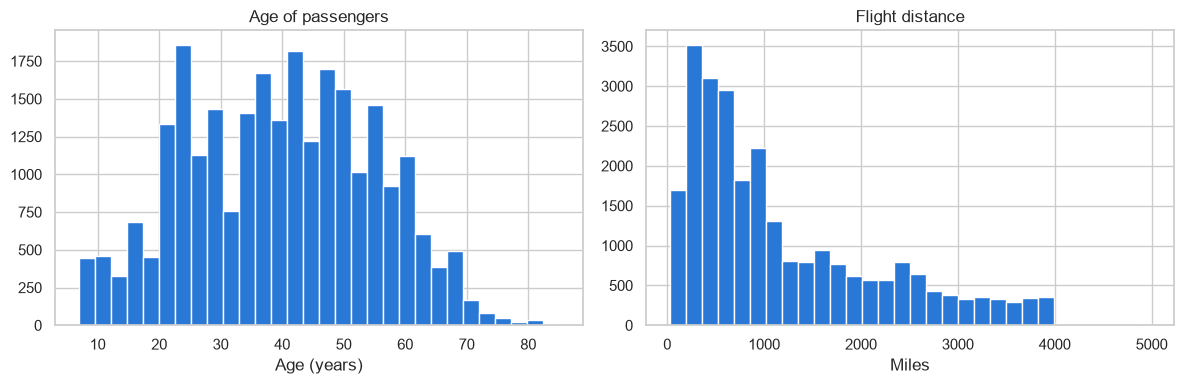

,age,flight_distance
count,25976.0,25976.0
mean,39.6,1193.8
std,15.1,998.7
min,7.0,31.0
25%,27.0,414.0
50%,40.0,849.0
75%,51.0,1744.0
max,85.0,4983.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(clean_df["age"], bins=30, color=BLUE, edgecolor="white")
axes[0].set_title("Age of passengers")
axes[0].set_xlabel("Age (years)")
axes[1].hist(clean_df["flight_distance"], bins=30, color=BLUE, edgecolor="white")
axes[1].set_title("Flight distance")
axes[1].set_xlabel("Miles")
plt.tight_layout()
plt.show()

clean_df[["age", "flight_distance"]].describe().round(1)

- Passengers are **7 to 85** years old; the average age is about **40**.
- Most flights are short: half are under **849 miles**, but a few long flights go up to almost 5,000 miles.

### 6.4 Delays

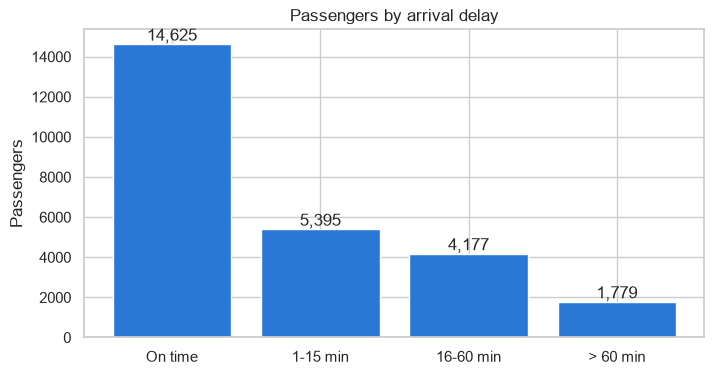

In [20]:
fig, ax = plt.subplots()
plot_counts("delay_group", ax, "Passengers by arrival delay")
plt.show()

More than half of the passengers (**56 %**) arrived on time; about **7 %** arrived more than one hour late.

### 6.5 Service ratings

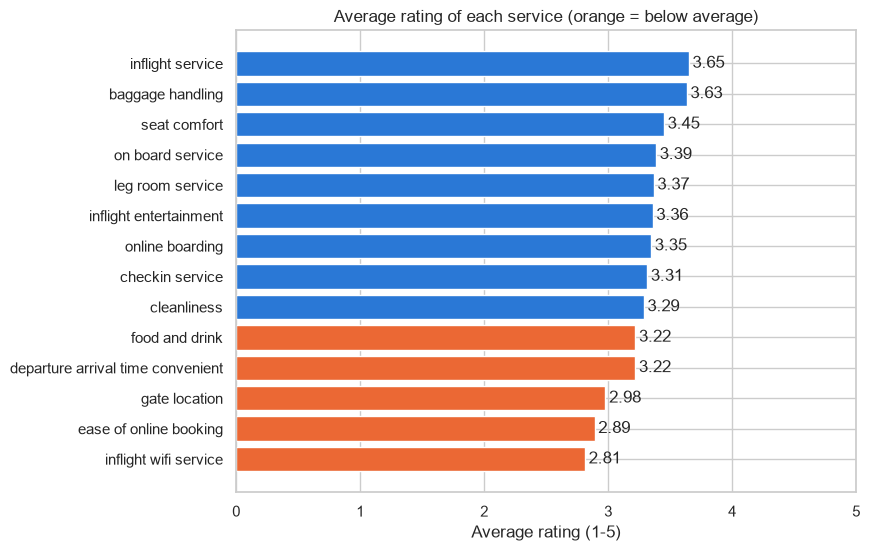

In [21]:
average_ratings = clean_df[service_columns].mean().sort_values()
plt.figure(figsize=(8, 6))
plt.barh(average_ratings.index.str.replace("_", " "), average_ratings,
         color=[ORANGE if rating < average_ratings.mean() else BLUE for rating in average_ratings])
for y, value in enumerate(average_ratings):
    plt.text(value + 0.03, y, f"{value:.2f}", va="center")
plt.title("Average rating of each service (orange = below average)")
plt.xlabel("Average rating (1-5)")
plt.xlim(0, 5)
plt.show()

The weakest services are **inflight wifi (2.81)**, **online booking (2.89)** and **gate location (2.98)**. The best are **inflight service (3.65)** and **baggage handling (3.63)**.

## 7. Bivariate & Multivariate Analysis (variables compared with satisfaction)

To check that a difference is real and not chance, we use:
- **Chi-square test** for groups: if the **p-value < 0.05** the difference is real. **Cramér's V** shows how strong the link is (0 = none, 0.5 = strong).
- **Mann-Whitney test** for numbers (like age), with the same p-value rule.

In [22]:
def chi_square_test(column):
    """Is satisfaction linked to this column? Returns the p-value and Cramér's V."""
    table = pd.crosstab(clean_df[column], clean_df["satisfaction"])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return round(p_value, 4), round(cramers_v, 2)

### 7.1 Q2 — Which passengers are more satisfied?

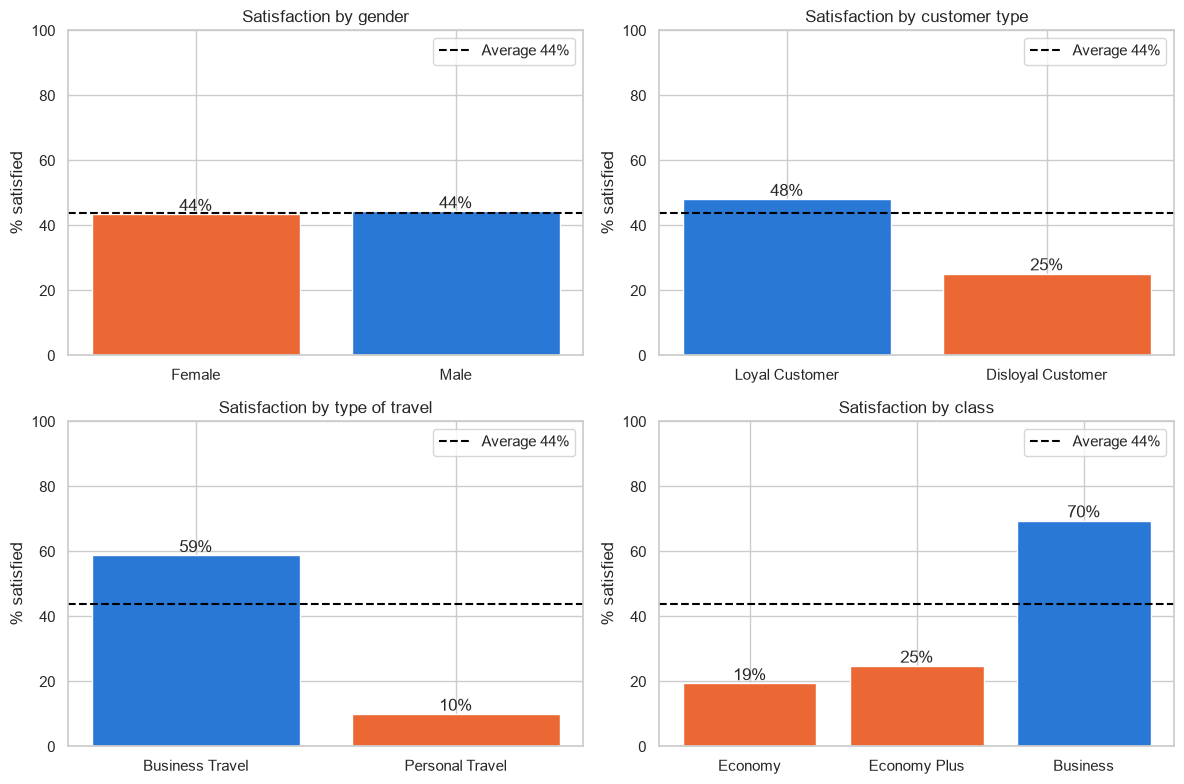

In [23]:
segments = ["gender", "customer_type", "type_of_travel", "class"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.flat, segments):
    plot_satisfaction_rate(column, ax, "Satisfaction by " + column.replace("_", " "))
plt.tight_layout()
plt.show()

In [24]:
tested_columns = segments + ["age_group", "distance_group", "delay_group"]
tests = pd.DataFrame([chi_square_test(column) for column in tested_columns],
                     index=tested_columns, columns=["p_value", "cramers_v"])
tests.sort_values("cramers_v", ascending=False)

,p_value,cramers_v
class,0.0000,0.50
type_of_travel,0.0000,0.45
distance_group,0.0000,0.28
age_group,0.0000,0.25
customer_type,0.0000,0.18
delay_group,0.0000,0.10
gender,0.2421,0.01


- **Class** and **travel purpose** matter most (Cramér's V 0.50 and 0.45): **70 %** of Business-class passengers are satisfied vs **19 %** in Economy; **59 %** of business travellers vs only **10 %** of personal travellers.
- **Loyal customers** are almost twice as satisfied (48 %) as disloyal ones (25 %).
- **Gender makes no difference** (p = 0.24 > 0.05).

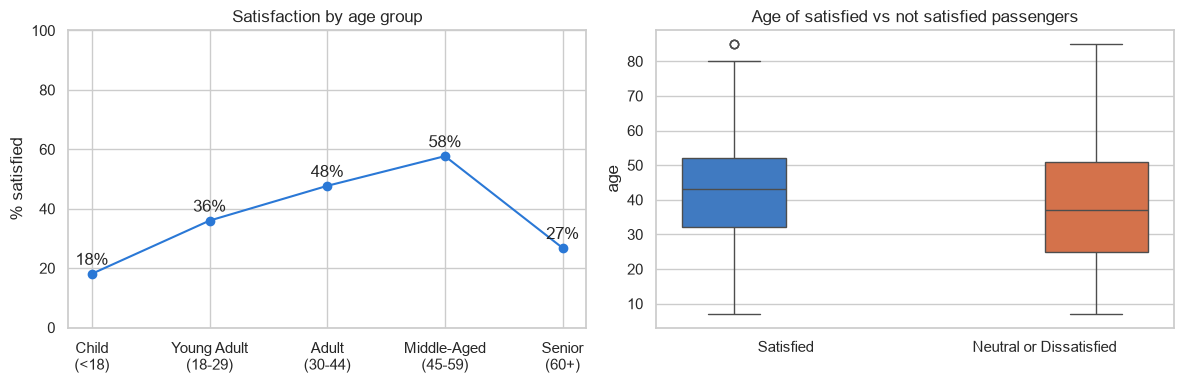

Median age: 43.0 vs 37.0 | p-value: 6.600710626409929e-98


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
age_rates = satisfaction_rate("age_group")
axes[0].plot([short_label(label) for label in age_rates.index], age_rates.values, marker="o", color=BLUE)
for x, value in enumerate(age_rates.values):
    axes[0].text(x, value + 3, f"{value:.0f}%", ha="center")
axes[0].set_title("Satisfaction by age group")
axes[0].set_ylabel("% satisfied")
axes[0].set_ylim(0, 100)
sns.boxplot(data=clean_df, x="satisfaction", y="age", hue="satisfaction",
            palette={"Satisfied": BLUE, "Neutral or Dissatisfied": ORANGE}, legend=False, ax=axes[1])
axes[1].set_title("Age of satisfied vs not satisfied passengers")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

# Mann-Whitney test: are satisfied passengers really older?
satisfied_age = clean_df.loc[clean_df["is_satisfied"] == 1, "age"]
other_age = clean_df.loc[clean_df["is_satisfied"] == 0, "age"]
print("Median age:", satisfied_age.median(), "vs", other_age.median(),
      "| p-value:", stats.mannwhitneyu(satisfied_age, other_age).pvalue)

**Middle-aged passengers (45–59)** are the happiest (**58 %**); children (18 %), young adults (36 %) and seniors (27 %) are the least satisfied. Satisfied passengers are older (median **43** vs **37**, p < 0.05).

### 7.2 Q3 — Which services matter most?

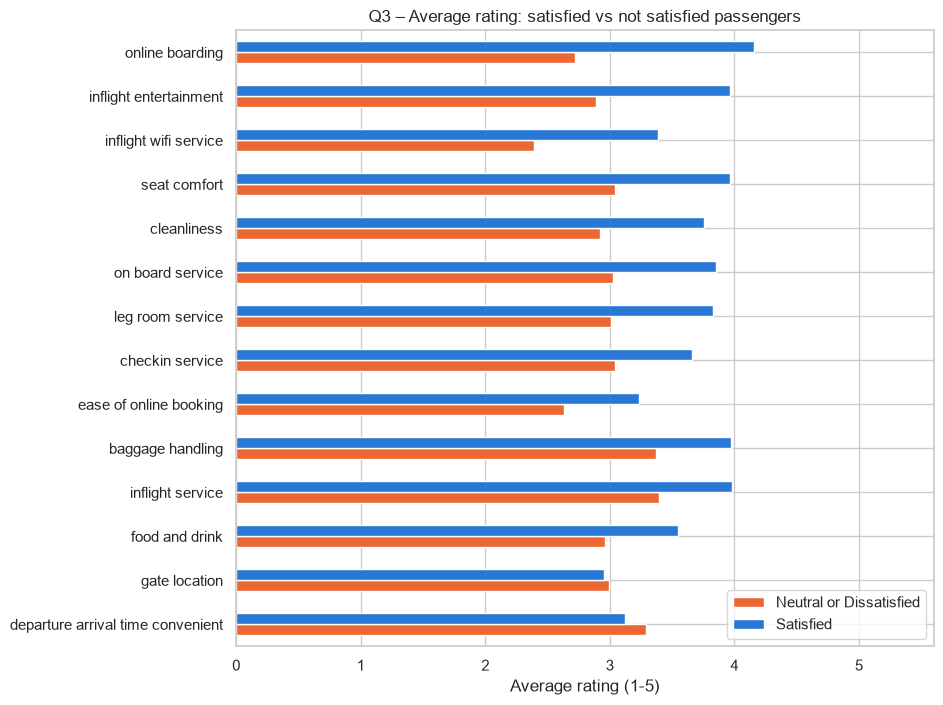

satisfaction,Satisfied,Neutral or Dissatisfied,gap
online boarding,4.16,2.72,1.44
inflight entertainment,3.96,2.89,1.08
inflight wifi service,3.39,2.39,1.00
seat comfort,3.97,3.04,0.92
cleanliness,3.76,2.92,0.84


In [26]:
service_means = clean_df.groupby("satisfaction", observed=True)[service_columns].mean().T
service_means["gap"] = service_means["Satisfied"] - service_means["Neutral or Dissatisfied"]
service_means = service_means.sort_values("gap")
service_means.index = service_means.index.str.replace("_", " ")

service_means[["Neutral or Dissatisfied", "Satisfied"]].plot(kind="barh", figsize=(9, 8), color=[ORANGE, BLUE])
plt.title("Q3 – Average rating: satisfied vs not satisfied passengers")
plt.xlabel("Average rating (1-5)")
plt.xlim(0, 5.6)
plt.legend(loc="lower right")
plt.show()

service_means.sort_values("gap", ascending=False).round(2).head(5)

The biggest difference between satisfied and unsatisfied passengers is in **online boarding (+1.44)**, then **inflight entertainment (+1.08)**, **wifi (+1.00)** and **seat comfort (+0.92)**. Wifi matters a lot but is the **lowest-rated** service — the biggest opportunity.

### 7.3 Q4 — Do delays reduce satisfaction?

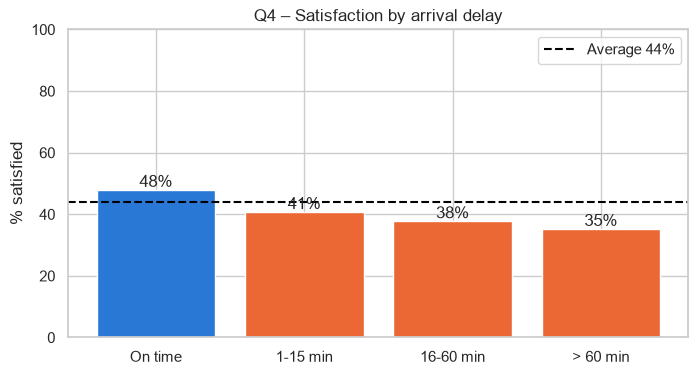

In [27]:
fig, ax = plt.subplots()
plot_satisfaction_rate("delay_group", ax, "Q4 – Satisfaction by arrival delay")
plt.show()

Yes, but only a little: satisfaction falls from **48 %** (on time) to **35 %** (more than one hour late). The link is real (p < 0.05) but weak (Cramér's V 0.10).

### 7.4 Q5 — Does flight distance matter?

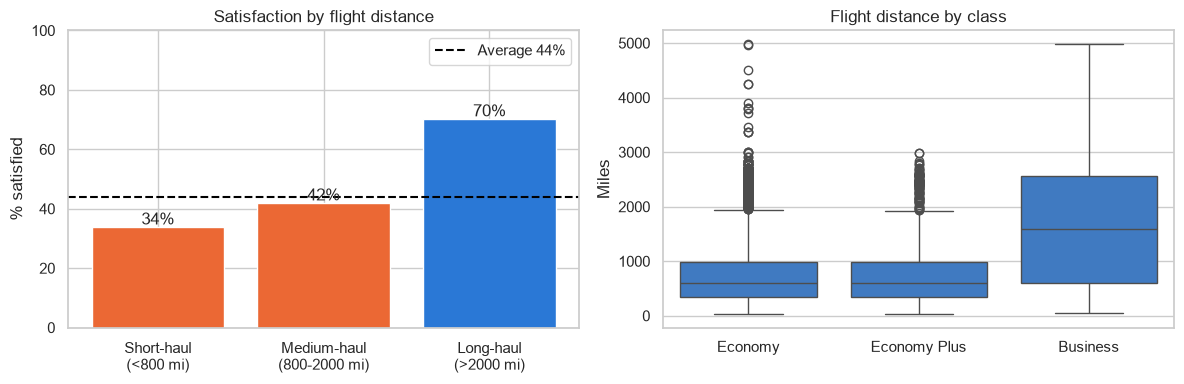

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_satisfaction_rate("distance_group", axes[0], "Satisfaction by flight distance")
sns.boxplot(data=clean_df, x="class", y="flight_distance", color=BLUE, ax=axes[1])
axes[1].set_title("Flight distance by class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Miles")
plt.tight_layout()
plt.show()

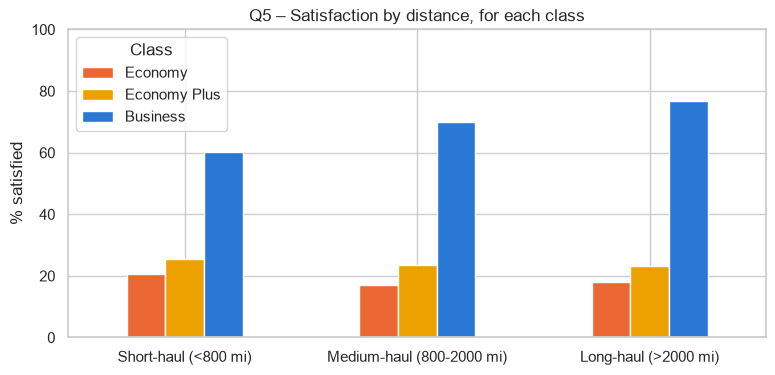

class,Economy,Economy Plus,Business
distance_group,,,
Short-haul (<800 mi),20.8,25.4,60.3
Medium-haul (800-2000 mi),16.9,23.7,70.0
Long-haul (>2000 mi),18.0,23.3,76.6


In [29]:
# Multivariate: the same distance chart, but for each class separately
distance_class = clean_df.pivot_table(index="distance_group", columns="class", values="is_satisfied",
                                      aggfunc="mean", observed=True) * 100
distance_class.plot(kind="bar", color=[ORANGE, YELLOW, BLUE], figsize=(9, 4), rot=0)
plt.title("Q5 – Satisfaction by distance, for each class")
plt.ylabel("% satisfied")
plt.xlabel("")
plt.ylim(0, 100)
plt.legend(title="Class", loc="upper left")
plt.show()

distance_class.round(1)

Long flights look happier (**70 %** vs **34 %** for short flights), but that is because long flights are mostly flown in **Business class**. Inside the same class, distance changes little (Economy: 17–21 % for every distance).

### 7.5 Q6 — Which travel purpose and class combination is happiest?

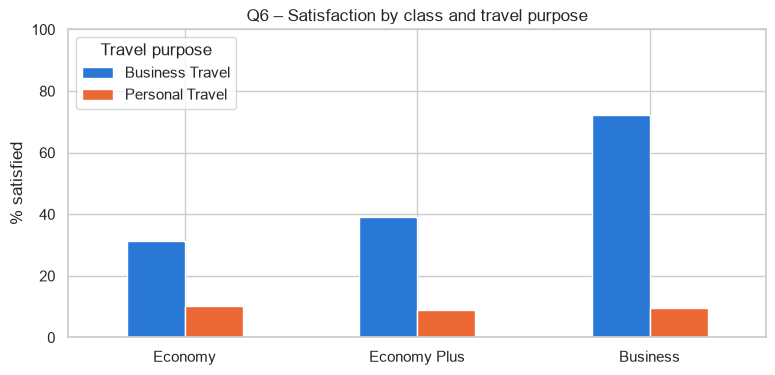

type_of_travel,Business Travel,Personal Travel
class,,
Economy,31.3,10.2
Economy Plus,39.0,8.8
Business,72.1,9.5


In [30]:
travel_class = clean_df.pivot_table(index="class", columns="type_of_travel", values="is_satisfied",
                                    aggfunc="mean", observed=True) * 100
travel_class.plot(kind="bar", color=[BLUE, ORANGE], figsize=(9, 4), rot=0)
plt.title("Q6 – Satisfaction by class and travel purpose")
plt.ylabel("% satisfied")
plt.xlabel("")
plt.ylim(0, 100)
plt.legend(title="Travel purpose", loc="upper left")
plt.show()

travel_class.round(1)

- **Happiest:** business travellers in Business class (**72 %**).
- **Unhappiest:** personal travellers — only about **9–10 %** are satisfied in **every** class, even Business.

## 8. Conclusions

| # | Question | Answer |
|---|---|---|
| Q1 | What share of passengers are satisfied? | Only **43.9 %** |
| Q2 | Which passengers are more satisfied? | **Business class (70 %)**, **business travellers (59 %)**, **loyal customers (48 %)** and **45–59-year-olds (58 %)**. Gender has **no effect** |
| Q3 | Which services matter most? | **Online boarding**, **entertainment**, **wifi** and **seat comfort**; wifi is also the **lowest-rated** service |
| Q4 | Do delays reduce satisfaction? | Yes, but weakly: **48 %** on time → **35 %** more than 1 hour late |
| Q5 | Does distance matter? | Only because long flights are mostly **Business class**; inside a class it changes little |
| Q6 | Happiest / unhappiest combination? | **Business travel + Business class: 72 %**; **personal travel: about 10 % in every class** |

### Recommendations
1. **Improve the digital journey:** wifi, online boarding and online booking.
2. **Upgrade Economy:** seat comfort, entertainment and leg room.
3. **Create offers for leisure travellers** — the least satisfied group.
4. **Win back disloyal customers** with loyalty offers.
5. **Keep delays short.**

### Limitations
- The survey shows links between variables, not causes.
- "Neutral" and "dissatisfied" are in the same group, so we cannot separate them.

*The clean data (`Data_Cleaned.csv`) is used by the Streamlit dashboard (`app.py`).*